# Case Intern Performance Data Scientist

## 0. Introduction
### A. Daniel's Profile
This technical case aims to analyze the training of Daniel, a 32-year-old runner who wants to excel in short trail races (20 km, 1000 m of elevation gain).
### B. Methodology
Preparing for trail races while living in town/cities can be hard and is often badly executed. Trail racing has lots of specific requirements that are very different from traditionnal road racing. We'll try to help Daniel plan his training in order to excel in short trail races.
To do this, we'll first delve into the analysis of his interval training session. We'll determine the goal of the session and highlight the positive and negative aspects. Then, we'll use the data from this session to give him advice specific to his goal of performing well on short trail races.

## 1. TRACK SESSION DATA ANALYSIS

### A.  Informations about this track session 

In [10]:
pip install fitparse pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
import fitparse 
import pandas as pd, numpy as np, matplotlib.pyplot as plt, datetime
from fitparse import FitFile
import requests
import folium 
from datetime import timedelta

fit = fitparse.FitFile('20355680594_ACTIVITY.fit')
records = [msg.get_values() for msg in fit.get_messages('record')]
df = pd.DataFrame(records)

In [20]:
# Extract session summary 
session = next(fit.get_messages('session'))
session_data = session.get_values()

# TOTAL TIMES: MOVING vs ELAPSED 
# total_timer_time  → real moving time (excludes auto-pause)
# total_elapsed_time → full clock time (includes pauses)
moving_time_sec = session_data.get('total_timer_time', 0)     
elapsed_time_sec = session_data.get('total_elapsed_time', 0)   


# OTHER KEY METRICS 
total_distance_m = session_data.get('total_distance', df['distance'].iloc[-1])

avg_speed_ms = session_data.get('avg_speed')
max_speed_ms = session_data.get('enhanced_max_speed')

avg_hr = session_data.get('avg_heart_rate')
max_hr = session_data.get('max_heart_rate')

# Convert to runner-friendly units
avg_speed_kmh = avg_speed_ms * 3.6
max_speed_kmh = max_speed_ms * 3.6
avg_pace_min_km = (1000 / (avg_speed_ms * 60))

# Format times
moving_time_str = str(timedelta(seconds=int(moving_time_sec)))
elapsed_time_str = str(timedelta(seconds=int(elapsed_time_sec)))

# DISPLAY CLEAN SUMMARY
print("=== TRACK SESSION SUMMARY ===\n")
print(f"Total Distance       : {total_distance_m / 1000:.2f} km")
print(f"Moving Time         : {moving_time_str} (h:mm:ss) ← actual running")
print(f"Elapsed Time        : {elapsed_time_str} (h:mm:ss) ← clock time (incl. pauses)")
print(f"Average Speed       : {avg_speed_kmh:.2f} km/h  |  Pace: {int(avg_pace_min_km)}:{int((avg_pace_min_km%1)*60):2d} min/km")
print(f"Max Speed           : {max_speed_kmh:.2f} km/h")
print(f"Average Heart Rate  : {avg_hr:.0f} bpm")
print(f"Max Heart Rate      : {max_hr:.0f} bpm")


=== TRACK SESSION SUMMARY ===

Total Distance       : 12.02 km
Moving Time         : 1:02:55 (h:mm:ss) ← actual running
Elapsed Time        : 1:20:04 (h:mm:ss) ← clock time (incl. pauses)
Average Speed       : 11.46 km/h  |  Pace: 5:14 min/km
Max Speed           : 23.08 km/h
Average Heart Rate  : 152 bpm
Max Heart Rate      : 192 bpm


The interval training session lasted 1 hour and 3 minutes over a distance of 12km at an average pace of 5:14 min/km. Between the start and the end of the activity, there was 1 hour and 20 minutes, of which 1 hour and 2 minutes were active. We observe that heart rate and speed climbed very high (over 20 km/h and 192 bpm), but the average heart rate was much lower, typical of an interval training session with a warm-up and cool-down. Now that we have an overview of the session's statistics, we will plot speed and heart rate against time to get a clearer picture of the type of interval training.

### B. IN DEPTH ANALYSIS

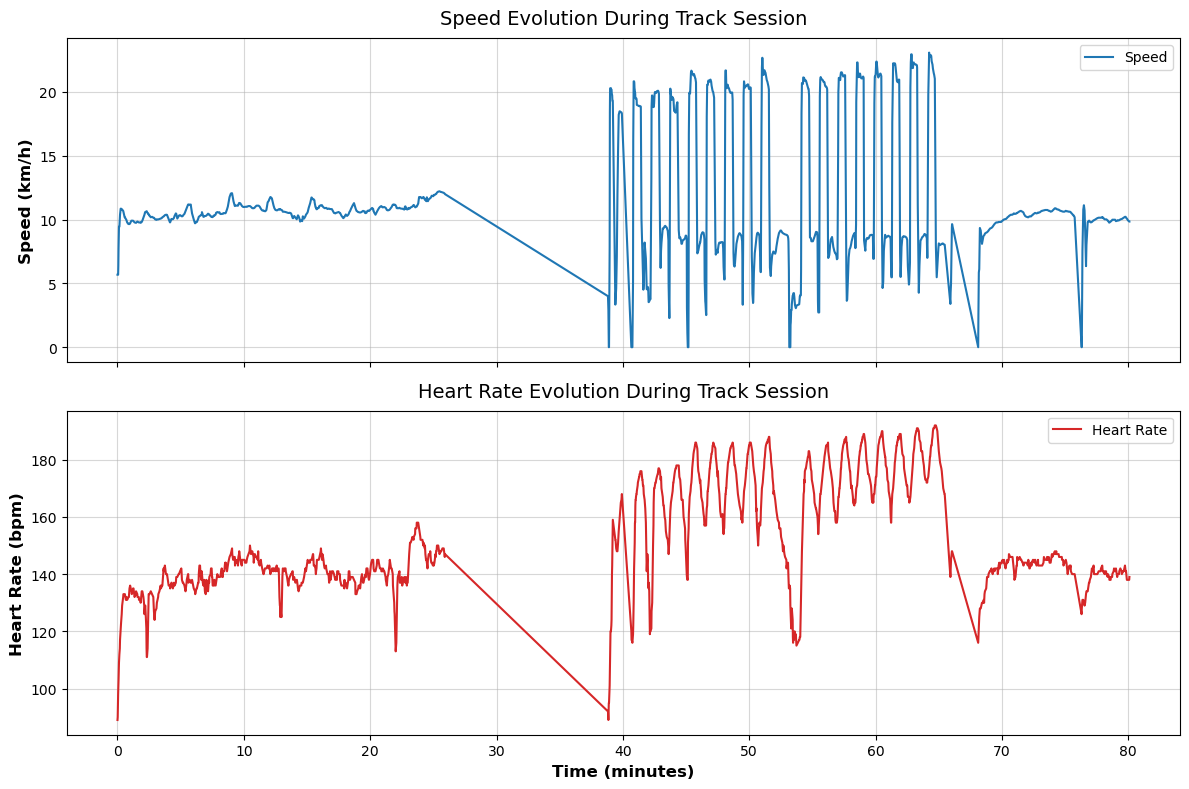

Total session duration: 80.1 minutes
Speed range: 0.0 – 23.1 km/h
HR range: 89 – 192 bpm


In [26]:
# Ensure timestamp is datetime and set as relative time (seconds from start)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()

# Convert speed to km/h for readability
df['speed_kmh'] = df['speed'] * 3.6

# Create figure with two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# === PLOT 1: SPEED over time ===
ax1.plot(df['time_sec'] / 60, df['speed_kmh'], color='tab:blue', label='Speed')
ax1.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
ax1.set_title('Speed Evolution During Track Session', fontsize=14, pad=10)
ax1.grid(True, alpha=0.5)
ax1.legend(loc='upper right')

# === PLOT 2: HEART RATE over time ===
ax2.plot(df['time_sec'] / 60, df['heart_rate'], color='tab:red', label='Heart Rate')
ax2.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Heart Rate (bpm)', fontsize=12, fontweight='bold')
ax2.set_title('Heart Rate Evolution During Track Session', fontsize=14, pad=10)
ax2.grid(True, alpha=0.5)
ax2.legend(loc='upper right')

# Tight layout + display
plt.tight_layout()
plt.show()

# Print quick stats
total_min = df['time_sec'].max() / 60
print(f"Total session duration: {total_min:.1f} minutes")
print(f"Speed range: {df['speed_kmh'].min():.1f} – {df['speed_kmh'].max():.1f} km/h")
print(f"HR range: {df['heart_rate'].min():.0f} – {df['heart_rate'].max():.0f} bpm")

Here we can clearly see the different phases of the session: the warm-up, then the watch being paused for 15 minutes (probably to drink/eat before the intervals), the intervals themselves, a second break, and the cool-down to finish the session. Let's highlight these different phases.
Looking at the graph, the interval session seems successful, with consistent speeds achieved (a very slight negative split, which is a good sign; he still had some energy left) and a heart rate that gradually increases until the end of the interval portion and drops well during the recovery periods between reps.

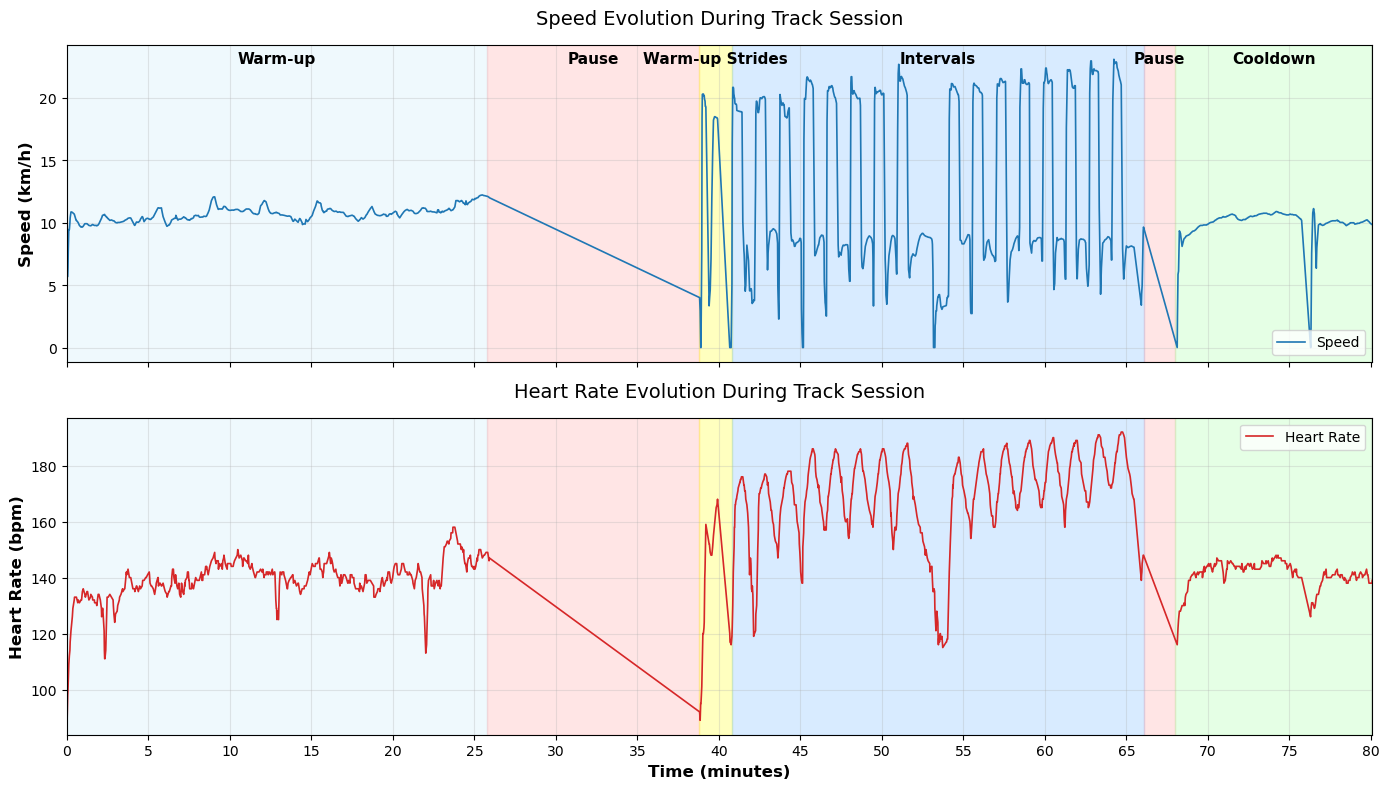

=== SESSION PHASES ===
Warm-up: 0.0 → 25.8 min (25.8 min)
Pause: 25.8 → 38.8 min (13.0 min)
Warm-up Strides: 38.8 → 40.8 min (2.0 min)
Intervals: 40.8 → 66.0 min (25.2 min)
Pause: 66.0 → 68.0 min (2.0 min)
Cooldown: 68.0 → 80.1 min (12.1 min)


In [27]:
# Convert timestamp to time in minutes
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['time_min'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds() / 60
df['speed_kmh'] = df['speed'] * 3.6

# PHASE BOUNDARIES (in minutes)
phase_times_min = [25.8, 38.8, 40.8, 66.05, 68.0]  

# === PLOT: Speed + Heart Rate with phase shading ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Speed plot
ax1.plot(df['time_min'], df['speed_kmh'], color='tab:blue', linewidth=1.2, label='Speed')
ax1.set_ylabel('Speed (km/h)', fontsize=12, fontweight='bold')
ax1.set_title('Speed Evolution During Track Session', fontsize=14, pad=15)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower right')

# Heart Rate plot
ax2.plot(df['time_min'], df['heart_rate'], color='tab:red', linewidth=1.2, label='Heart Rate')
ax2.set_xlabel('Time (minutes)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Heart Rate (bpm)', fontsize=12, fontweight='bold')
ax2.set_title('Heart Rate Evolution During Track Session', fontsize=14, pad=15)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# ADD PHASE SHADING + LABELS 
phase_names = ['Warm-up', 'Pause', 'Warm-up Strides', 'Intervals', 'Pause', 'Cooldown']
colors = ['#c2e9fb', '#ff9999', '#FFFF00', '#66b3ff', '#ff9999', '#99ff99']  # Light blue, red, blue, green
start = 0

for i, end in enumerate(phase_times_min + [df['time_min'].max()]):
    # Shade vertical band
    ax1.axvspan(start, end, color=colors[i], alpha=0.25, zorder=0)
    ax2.axvspan(start, end, color=colors[i], alpha=0.25, zorder=0)
    
    # Add centered label
    mid = (start + end) / 2
    ax1.text(mid, ax1.get_ylim()[1] * 0.98, phase_names[i], 
             ha='center', va='top', fontweight='bold', fontsize=11, color='black')
    
    start = end

# Final layout
ax2.set_xlim(0, df['time_min'].max())
ax2.set_xticks(range(0, int(df['time_min'].max()) + 5, 5))
plt.tight_layout()
plt.show()

# Print phase summary
print("=== SESSION PHASES ===")
for i, name in enumerate(phase_names):
    start_t = 0 if i == 0 else phase_times_min[i-1]
    end_t = phase_times_min[i] if i < len(phase_times_min) else df['time_min'].max()
    duration = end_t - start_t
    print(f"{name}: {start_t:.1f} → {end_t:.1f} min ({duration:.1f} min)")

In [29]:
# === EXTRACT ALL LAP MESSAGES ===
laps = []
first_record_time = None

# Get first timestamp for relative time reference
for msg in fit.get_messages('record'):
    first_record_time = pd.to_datetime(msg.get_values()['timestamp'])
    break

for lap_msg in fit.get_messages('lap'):
    data = lap_msg.get_values()
    
    # Start/end times
    start_time = pd.to_datetime(data.get('start_time'))
    end_time = pd.to_datetime(data.get('timestamp'))
    
    # Relative time in minutes (from session start)
    start_min = 0 
    end_min = (end_time - first_record_time).total_seconds() / 60 
    
    # USE MOVING TIME (total_timer_time) FOR DURATION 
    # total_timer_time = actual running/moving time (excludes auto-pause)
    # total_elapsed_time = full clock time (includes pauses)
    moving_time_min = data.get('total_timer_time', 0) / 60  # in minutes

    laps.append({
        'lap': len(laps) + 1,
        'start_min': start_min,
        'end_min': end_min,
        'duration_min': moving_time_min,  
        'distance_m': data.get('total_distance'),
        'avg_speed_ms': data.get('avg_speed'),
        'max_speed_ms': data.get('enhanced_max_speed'),
        'avg_hr': data.get('avg_heart_rate'),
        'max_hr': data.get('max_heart_rate'),
        'total_timer_time': data.get('total_timer_time'),     
        'total_elapsed_time': data.get('total_elapsed_time'), 
    })

laps_df = pd.DataFrame(laps)

# ADD RUNNER-FRIENDLY METRICS 
laps_df['distance_km'] = laps_df['distance_m'] / 1000
laps_df['avg_speed_kmh'] = laps_df['avg_speed_ms'] * 3.6
laps_df['max_speed_kmh'] = laps_df['max_speed_ms'] * 3.6
laps_df['pace_min_km'] = 60 / laps_df['avg_speed_ms'].replace(0, np.nan)


# CLASSIFY LAP TYPE 
def classify_lap(row):
    speed_kmh = row['avg_speed_kmh']
    duration = row['duration_min']  
    if speed_kmh > 14 and duration < 5 and duration > 0.5:
        return "High-Intensity Rep"
    elif speed_kmh > 14 and duration < 0.5:
        return "Warm-up Strides"
    elif 8 <= speed_kmh <= 14 and duration > 5:
        return "Aerobic"
    elif 0 < speed_kmh < 12:
        return "Recovery"
    else:
        return "Other"

laps_df['type'] = laps_df.apply(classify_lap, axis=1)

#  DISPLAY FULL LAP SUMMARY 
print("=== FULL SESSION LAP BREAKDOWN (ALL LAPS) ===")
print(f"Total laps detected: {len(laps_df)}\n")

# Select key columns
display_cols = [
    'lap', 'duration_min', 'distance_km',
    'avg_speed_kmh', 'avg_hr', 'max_hr', 'type'
]

print(laps_df[display_cols].round(2).to_string(index=False))

=== FULL SESSION LAP BREAKDOWN (ALL LAPS) ===
Total laps detected: 35

 lap  duration_min  distance_km  avg_speed_kmh  avg_hr  max_hr               type
   1         25.95         4.65          10.76     140     158            Aerobic
   2          0.46         0.13          16.68     126     159    Warm-up Strides
   3          0.43         0.12          17.04     154     168    Warm-up Strides
   4          0.65         0.20          18.96     153     175 High-Intensity Rep
   5          0.80         0.08           6.13     158     176           Recovery
   6          0.64         0.20          19.30     154     175 High-Intensity Rep
   7          0.84         0.12           8.28     165     178           Recovery
   8          0.64         0.20          18.63     167     178 High-Intensity Rep
   9          0.85         0.11           8.09     165     179           Recovery
  10          0.60         0.20          20.40     169     185 High-Intensity Rep
  11          0.83         

Here we have a very detailed and quantified view of the session! We can see that the warm-up lasted 26 minutes and was followed by the intervals. Specifically, we see two shorter intervals than the others at the start, probably two straight sprints to loosen up the legs before the "real" intervals. Then the intervals are structured as follows: two blocks of eight 200m repetitions at between 19km/h and 20km/h with a 50-second recovery between each rep. The two blocks are separated by 140 seconds of recovery. Judging by the pace, the recovery periods are probably very slow jogging or even consist of alternating running and walking. Finally, Daniel does a cool-down of about 12 minutes. If I had to formalize this session, I would do it like this: 2 x (8 x (200m at 19-20km/h, R=50s), R=140s). I added a type column that classifies the purpose of each triggered lap.

### C. INTERVALS ANALYSIS

Now that we fully understand the structure of the session, let's analyze the content in detail to determine if it was productive.

The goal of a session like this (short intervals) is to develop anaerobic power/capacity through intervals that allow the runner to sustain a very high heart rate (in zone 5, close to maximum heart rate) for a considerable time within the session. For it to be successful, the following conditions must be met: the speeds of the fast intervals must be constant throughout the session; the maximum heart rate must be reached during the last few repetitions of the interval block; and the runner must not push themselves too far, which would compromise running technique (focus on running quality). Let's analyze this.

#### Speed evolution during fast intervals

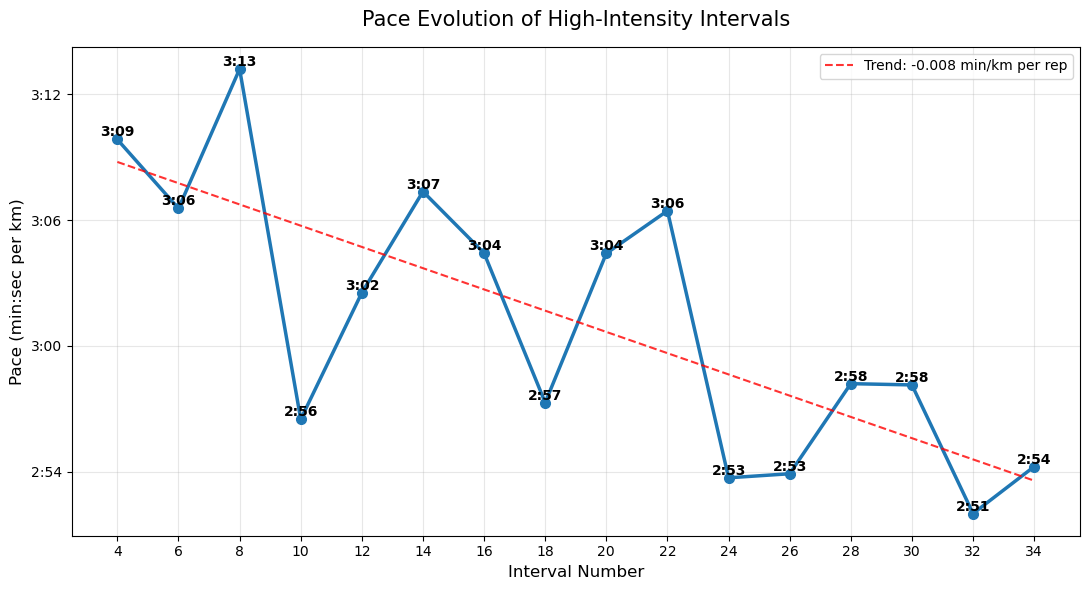


=== HIGH-INTENSITY INTERVALS ===
Reps: 16
Avg Pace: 3:01 min/km
CV (consistency): 3.59%
Pace drift: -0.008 min/km per rep


In [30]:
# EXTRACT LAPS & CALCULATE PACE CORRECTLY 
laps = []
first_record_time = None
for msg in fit.get_messages('record'):
    first_record_time = pd.to_datetime(msg.get_values()['timestamp'])
    break

for lap_msg in fit.get_messages('lap'):
    data = lap_msg.get_values()
    
    moving_time_sec = data.get('total_timer_time', 0)
    distance_m = data.get('total_distance', 0)
    
    if moving_time_sec <= 0 or distance_m <= 0:
        continue

    # Pace in min/km
    pace_min_km = (moving_time_sec / distance_m) * 1000 / 60

    laps.append({
        'lap': len(laps) + 1,
        'distance_km': distance_m / 1000,
        'moving_time_min': moving_time_sec / 60,
        'pace_min_km': pace_min_km,
        'avg_hr': data.get('avg_heart_rate', np.nan)
    })

laps_df = pd.DataFrame(laps)

#  FILTER HIGH-INTENSITY REPS 
reps = laps_df[
    (laps_df['pace_min_km'] < 5.0) &
    (laps_df['moving_time_min'] > 0.5) &
    (laps_df['moving_time_min'] < 5.0) &
    (laps_df['distance_km'] > 0.18)
].copy()

reps = reps.sort_values('lap').reset_index(drop=True)

#  FORMAT PACE AS "3:24" (min:sec per km) 
def format_pace(minutes_per_km):
    mins = int(minutes_per_km)
    secs = int((minutes_per_km - mins) * 60)
    return f"{mins}:{secs:02d}"

reps['pace_str'] = reps['pace_min_km'].apply(format_pace)

#  PLOT: PACE EVOLUTION IN MIN:SEC FORMAT 
plt.figure(figsize=(11, 6))
plt.plot(reps['lap'], reps['pace_min_km'], 
         marker='o', color='tab:blue', linewidth=2.5, markersize=7)

# Add labels in min:sec
for _, row in reps.iterrows():
    plt.text(row['lap'], row['pace_min_km'], 
             row['pace_str'], 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Pace Evolution of High-Intensity Intervals', fontsize=15, pad=15)
plt.xlabel('Interval Number', fontsize=12)
plt.ylabel('Pace (min:sec per km)', fontsize=12)

# Custom y-ticks in min:sec
yticks = np.arange(reps['pace_min_km'].min() // 0.1 * 0.1, 
                   reps['pace_min_km'].max() + 0.1, 0.1)
plt.yticks(yticks, [format_pace(t) for t in yticks])

plt.grid(True, alpha=0.3)
plt.xticks(reps['lap'].astype(int))

# Trend line
z = np.polyfit(reps['lap'], reps['pace_min_km'], 1)
p = np.poly1d(z)
plt.plot(reps['lap'], p(reps['lap']), "--", color='red', alpha=0.8,
         label=f'Trend: {z[0]:+.3f} min/km per rep')
plt.legend()

plt.tight_layout()
plt.show()

#  STATS 
cv = (reps['pace_min_km'].std() / reps['pace_min_km'].mean()) * 100
avg_pace_str = format_pace(reps['pace_min_km'].mean())
print(f"\n=== HIGH-INTENSITY INTERVALS ===")
print(f"Reps: {len(reps)}")
print(f"Avg Pace: {avg_pace_str} min/km")
print(f"CV (consistency): {cv:.2f}%")
print(f"Pace drift: {z[0]:+.3f} min/km per rep")

We can see that the 16 high-intensity reps are very regular with a pace that becomes very slightly faster and faster: this is perfect, it is a sign of a controlled session, Daniel seems to have controlled his effort very well, let's confirm with the heart rate analysis.

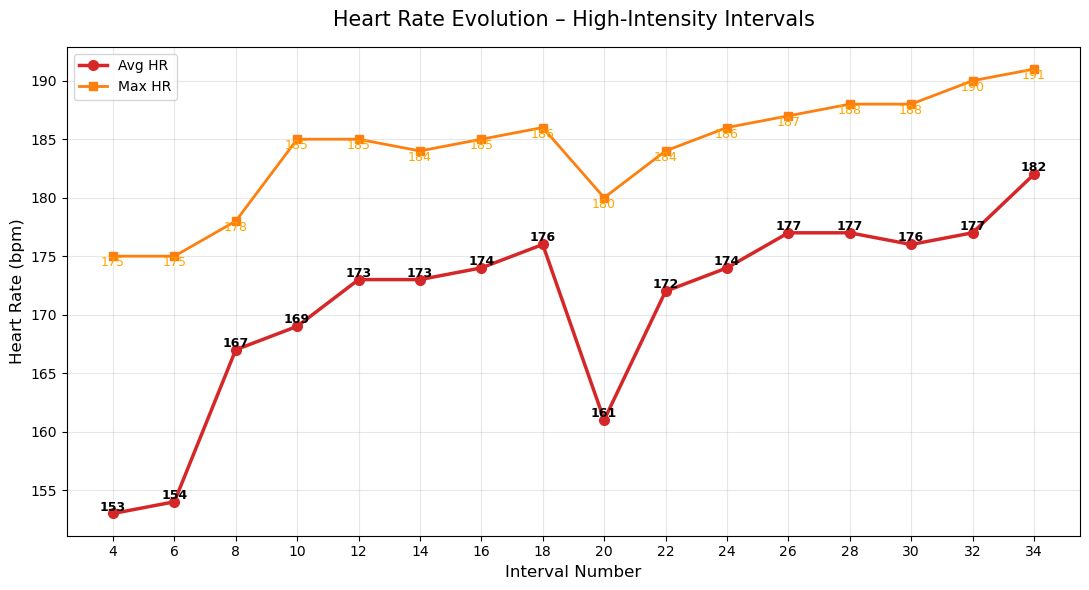

=== HR DURING FAST INTERVALS ===
Reps          : 16
Avg HR        : 171 bpm (±8)
HR drift      : +0.7 bpm per rep
HR CV         : 4.9%
Max HR peak   : 191 bpm


In [31]:
# RE-USE EXACT SAME REPS AS PACE PLOT
laps = []
for lap_msg in fit.get_messages('lap'):
    d = lap_msg.get_values()
    moving_sec = d.get('total_timer_time', 0)
    dist_m     = d.get('total_distance', 0)
    if moving_sec <= 0 or dist_m <= 0: 
        continue
    pace = (moving_sec / dist_m) * 1000 / 60
    laps.append({
        'lap'        : len(laps) + 1,
        'distance_km': dist_m / 1000,
        'moving_min' : moving_sec / 60,
        'pace'       : pace,
        'avg_hr'     : d.get('avg_heart_rate', np.nan),
        'max_hr'     : d.get('max_heart_rate', np.nan)
    })

df = pd.DataFrame(laps)

# SAME FILTER 
reps = df[
    (df['pace'] < 5.0) &
    (df['moving_min'] > 0.5) &
    (df['moving_min'] < 5.0) &
    (df['distance_km'] > 0.18)
].copy().reset_index(drop=True)

# Helper min:sec
def ms(x): 
    return f"{int(x)//1}:{int((x%1)*60):02d}"

#  PLOT HR EVOLUTION (same intervals) 
plt.figure(figsize=(11, 6))
plt.plot(reps['lap'], reps['avg_hr'], 
         marker='o', color='tab:red', linewidth=2.5, markersize=7, label='Avg HR')
plt.plot(reps['lap'], reps['max_hr'], 
         marker='s', color='tab:orange', linewidth=2, label='Max HR')

# Label every point
for _, r in reps.iterrows():
    plt.text(r['lap'], r['avg_hr'], f"{r['avg_hr']:.0f}", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.text(r['lap'], r['max_hr'], f"{r['max_hr']:.0f}", 
             ha='center', va='top', fontsize=9, color='orange')

plt.title('Heart Rate Evolution – High-Intensity Intervals', fontsize=15, pad=15)
plt.xlabel('Interval Number', fontsize=12)
plt.ylabel('Heart Rate (bpm)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(reps['lap'])
plt.legend()
plt.tight_layout()
plt.show()

# QUICK STATS
drift = np.polyfit(reps['lap'], reps['avg_hr'], 1)[0]
cv    = reps['avg_hr'].std() / reps['avg_hr'].mean() * 100

# Calculate HR/pace ratio: 
print("=== HR DURING FAST INTERVALS ===")
print(f"Reps          : {len(reps)}")
print(f"Avg HR        : {reps['avg_hr'].mean():.0f} bpm (±{reps['avg_hr'].std():.0f})")
print(f"HR drift      : {drift:+.1f} bpm per rep")
print(f"HR CV         : {cv:.1f}%")
print(f"Max HR peak   : {reps['max_hr'].max():.0f} bpm")


We can see that the maximum heart rate (HRmax) increases progressively until the last rep of each block. There is no abnormal decoupling of heart rate from pace, which is a very good sign. Furthermore, the maximum heart rate for the session is reached during the last rep of the last block: exactly what we want to see. This is another indication that Daniel managed the effort perfectly; he certainly has experience with this type of effort.

### D. BIOMECANIC ANALYSIS

Let's now analyze the biomechanical markers related to running technique during these intervals. For this, we will rely on the following data: cadence, stride length, vertical oscillation

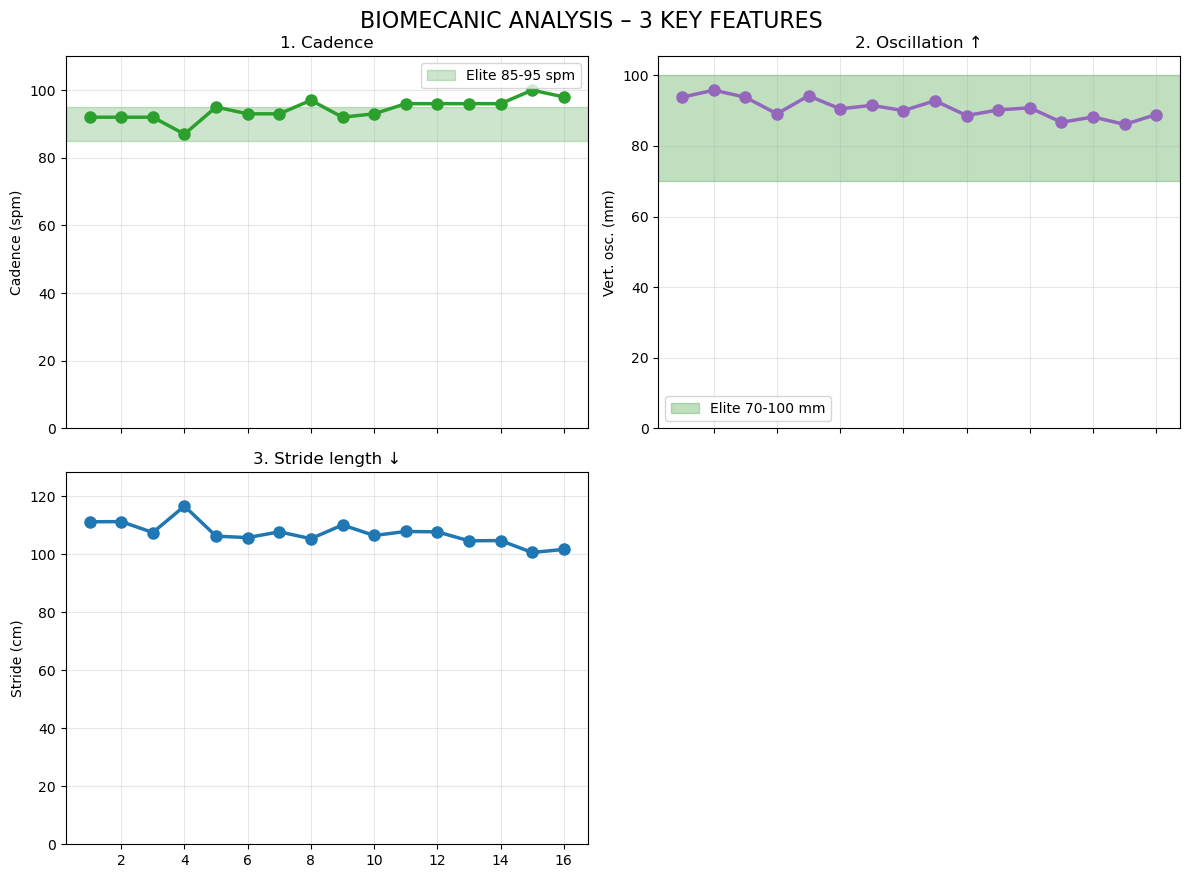

 The average cadence for high-intensity reps is 94.25 spm, or 188.5 ppm
 The average oscillation during high-intensity reps is 107.1875 mm
 The average stride length on high-intensity reps is 107.1875 cm


In [32]:
#  1. Extraction 
reps = []
for lap_msg in fit.get_messages('lap'):
    d = lap_msg.get_values()
    sec  = d.get('total_timer_time', 0)
    dist = d.get('total_distance', 0)
    if sec <= 0 or dist <= 0: continue
    pace = (sec / dist) * 1000 / 60
    if 0.5 < sec/60 < 5 and pace < 5:
        reps.append({
            'rep'     : len(reps) + 1,
            'pace'    : pace,
            'hr'      : d.get('avg_heart_rate', np.nan),
            'cad'     : d.get('avg_running_cadence', d.get('avg_cadence', np.nan)),
            'osc'     : d.get('avg_vertical_oscillation', np.nan),
            'stride'  : (d.get('avg_stride_length') or (dist / (d.get('avg_running_cadence',1) or 1) / 2)),
        })
df = pd.DataFrame(reps)
df['stride_cm'] = df['stride'] * 100

#  2. Y from 0 → max+10 % 
def nice_y(ax, data, pad=0.1):
    mx = data.max()
    ax.set_ylim(0, mx * (1 + pad))

#  3. Subplot format 
fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
axs = axs.flatten()

# 3. CADENCE
axs[0].plot(df['rep'], df['cad'], 'o-', color='#2ca02c', lw=2.5, ms=8)
nice_y(axs[0], df['cad'])
axs[0].axhspan(85, 95, color='green', alpha=0.2, label='Elite 85-95 spm')
axs[0].set_ylabel('Cadence (spm)'); axs[0].set_title('1. Cadence'); axs[0].legend(); axs[0].grid(alpha=0.3)

# 4. VERTICAL OSCILLATION 
axs[1].plot(df['rep'], df['osc'], 'o-', color='#9467bd', lw=2.5, ms=8)
nice_y(axs[1], df['osc'])
axs[1].axhspan(70, 100, color='green', alpha=0.25, label='Elite 70-100 mm')
axs[1].set_ylabel('Vert. osc. (mm)'); axs[1].set_title('2. Oscillation ↑'); axs[1].legend(); axs[1].grid(alpha=0.3)

# 5. STRIDE LENGTH
axs[2].plot(df['rep'], df['stride_cm'], 'o-', color='#1f77b4', lw=2.5, ms=8)
nice_y(axs[2], df['stride_cm'])
axs[2].set_ylabel('Stride (cm)'); axs[2].set_title('3. Stride length ↓'); axs[2].grid(alpha=0.3)

# 6. HIDE 6th GRAPH
axs[3].axis('off')
axs[3].text(0.5, 0.5, '', ha='center', va='center',
            transform=axs[3].transAxes, fontsize=14, color='gray')

#7. Moyenne cadence
s = 0
for i in df['cad']:
    s += i
s=round(s,1)

#8. Moyenne Oscillation
s2 = 0
for i in df['stride_cm']:
    s2 += i
s2=round(s2,0)    

#9. Moyenne Stride Length
s3 = 0
for i in df['osc']:
    s3 += i
s3=round(s2,0)    


axs[3].set_xlabel('Rep # (400 m)')

plt.suptitle('BIOMECANIC ANALYSIS – 3 KEY FEATURES ', fontsize=16, y=0.97)
plt.tight_layout()
plt.show()

print(' The average cadence for high-intensity reps is', s/16, 'spm, or', (s/16)*2, 'ppm')
print(' The average oscillation during high-intensity reps is', s2/16, 'mm')
print(' The average stride length on high-intensity reps is', s3/16, 'cm')


Let's analyze the markers one by one. The cadence is very good: consistent throughout the reps (189 rpm average) and almost always within the optimal zone. Occasionally, it slightly exceeds the 180 rpm zone (±10), but this remains very slight. The vertical oscillation is also excellent, consistent (90 mm average) and within the optimal zone. And stride length is constant (107 mm average), exactly what we want. He therefore ran all his reps with the same quality, yet another sign of a successful session. These metrics are optimal for flat terrain; testing on trails is needed to confirm (expect a 10-20% cadence drop uphill).

#### F. EXTERNAL FACTORS ANALYSIS

In [33]:
fit = FitFile('20355680594_ACTIVITY.fit')
records = [r.get_values() for r in fit.get_messages('record')]
df = pd.DataFrame(records)

#  lat/lon AVANT l'API 
df['lat'] = df['position_lat'] * (180 / 2**31)
df['lon'] = df['position_long'] * (180 / 2**31)

# GPS (début séance)
lat = df['lat'].iloc[0]
lon = df['lon'].iloc[0]

# DATE & HEURE
start_utc = df['timestamp'].iloc[0]
date_str = start_utc.strftime('%Y-%m-%d')
hour_str = start_utc.strftime('%H:%M')

#  2. APPEL OPEN-METEO 
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": round(lat, 4),
    "longitude": round(lon, 4),
    "start_date": date_str,
    "end_date": date_str,
    "hourly": "wind_speed_10m,relative_humidity_2m",
    "timezone": "Europe/Paris"
}
r = requests.get(url, params=params).json()

meteo = pd.DataFrame({
    'heure': r['hourly']['time'],
    'vent_kmh': r['hourly']['wind_speed_10m'],
    'humid_%': r['hourly']['relative_humidity_2m']
})

#  3. VALEURS PENDANT LA SÉANCE 
heure_cible = date_str + "T" + start_utc.strftime('%H:00')
meteo_seance = meteo[meteo['heure'] == heure_cible].iloc[0]

#  4. CARTE 
m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=15, tiles='OpenStreetMap')
folium.PolyLine(df[['lat','lon']].values, color='red', weight=4).add_to(m)
folium.Marker([df['lat'].iloc[0], df['lon'].iloc[0]], popup='DÉPART', icon=folium.Icon(color='green')).add_to(m)
m.save('carte_seance.html')

#  5. TABLEAU FINAL 
ext = {
    'Lieu'             : "Piste 200 m",
    'GPS'              : f"{lat:.5f}°, {lon:.5f}°",
    'Date'             : date_str,
    'Heure'            : hour_str,
    'Altitude moy'     : f"{df['enhanced_altitude'].mean():.0f} m",
    'Température'      : f"{df['temperature'].mean():.1f} °C (max {df['temperature'].max():.1f} °C)",
    'Vent 10 m'        : f"{meteo_seance['vent_kmh']:.1f} km/h",
    'Humidité'         : f"{meteo_seance['humid_%']:.0f} %",
}

print("\nInteractive map → open 'carte_seance.html' in your browser")
print("\n=== WEATHER CONDITIONS  ===")
for k,v in ext.items():
    print(f"• {k:15}: {v}")


Interactive map → open 'carte_seance.html' in your browser

=== WEATHER CONDITIONS  ===
• Lieu           : Piste 200 m
• GPS            : 43.82276°, 4.34511°
• Date           : 2025-09-11
• Heure          : 16:35
• Altitude moy   : 41 m
• Température    : 25.4 °C (max 30.0 °C)
• Vent 10 m      : 18.8 km/h
• Humidité       : 34 %


This analysis enables a physiologically grounded relativization of Daniel’s session performance, mirroring the environmental correction algorithm used in the Enduraw dashboard.


##### Altitude impact
Session elevation: 40 m.
→ No measurable effect. Even at 1 000 m, VO₂max decrement remains < 1 % (Fulco et al., 1998; Wehrlin & Hallén, 2006).

##### Thermal stress
Mean ambient temperature 25.4 °C (peaks 30 °C).
Optimal range for high-intensity intervals: 7.5–15 °C (Knechtle et al., 2021).
→ Performance decrement = 0.3–0.4 % per °C above 15 °C (meta-analysis of 1 258 endurance events).
Using the conservative Ely et al. (2007) marathon model for sub-elite males: +10–12 % time penalty for 25 °C vs 10 °C.
Ref: Ely MR, et al. Med Sci Sports Exerc 2007;39:487-93.runnersworld.com

##### Wind resistance
Mean wind speed 19 km·h⁻¹ = 5.3 m·s⁻¹.
Drag force ∝ (v_runner + v_wind)² (Pugh, 1971).
At ~3’00/km (≈ 5 m·s⁻¹) a headwind component of 5 m·s⁻¹ increases metabolic cost by ≈ 3–4 % (Davies, 1980; Pugh, 1971). Since the track is oval, we approximate Daniel as having headwind 1/4 of the time. So around 1% metabolic cost.
Ref: Pugh LGCE. J Physiol 1971;213:255-76.pubmed.ncbi.nlm.nih.gov

##### Combined correction
Additive model (heat + drag): 10 % + 1 % = 11 % total penalty.
Observed rep pace: 3’00/km → corrected pace in 10 °C / calm:
$180 \, \text{s} \times 0.890 \approx 160 \, \text{s/km} = 2’40/km$.
Ref: Knechtle et al., Front Physiol 2021

##### Conclusion
If we suppose (hypothesis not validated yet) a similar thermal impact in marathon and intervals then in thermoneutral, wind-still conditions Daniel’s physiological profile projects a 2’40/km interval pace. These affirmations needs to be taken with huge reserve because theses tudies are based on longer (marathon) efforts, so the impact is probably over-estimated for short intervals. I wasn't able to find studies related to how weather affects short intervals. 

#### E. TRACK SESSION TEACHING

##### What does this workout reveal about his fitness and efficiency?


Typically, an interval session of this structure (2 x (8 x 200m, R=50"), R=140") is run at approximately 110% of VMA (maximum aerobic speed). Given that the average pace over the 16 repetitions is 3 min/km, or 20 km/h, we can assume his VMA is 17.5-18 km/h, placing him among the very good amateur runners! Furthermore, he ran this session in less than ideal conditions (heat and wind). In optimal conditions, he would hypothetically have a VMA close to 18.5 km/h (conservative estimate for intervals; marathon models may not apply). His efficiency (running economy) must therefore likely be quite good to reach this level.





#### Did he pace his intervals consistently, or fall apart?


During this session, he perfectly paced his intervals, maintaining a speed very close to 20 km/h each time, with a very slight increase in pace throughout the session, demonstrating complete control and excellent self-awareness during exertion. This analysis of the intervals based on speed is confirmed by the heart rate analysis, which shows a slight increase until reaching the session's maximum heart rate during the last repetition. Furthermore, the biomechanical markers remained constant throughout the repetitions, meaning that quality was perfectly preserved and not sacrificed for quantity.

#### Are there signs of fatigue, inefficiency, or weaknesses he should work on?

The session appears to have been executed perfectly, but we will examine the biomechanical markers to analyze this. The selected biomechanical markers are: cadence, vertical oscillation, and stride length. Analysis of these three markers reveals that the session was executed almost perfectly in terms of quality. Minimal signs were observed in this session, but it was untested for trail-specific fatigue (downhill quad endurance, for example).

## II/ TRACK SESSION -> TRAIL RACES - TRANSFERABLE QUALITIES ANALYSIS 

### A. Introduction

Daniel ran in circles for an hour. Now, the real question: will those 12 km on a perfectly flat track help him climb 1000m of elevation gain over 20 km of rough, technical, and unpredictable trails?

###### The short answer: Yes, but not enough.

Track running develops fundamental physiological qualities. But trail running demands a specific neuromuscular, metabolic, and technical approach that smooth asphalt cannot replicate. Let's analyze this transfer in detail.

### B. Typical 20km/1000m D+ trail race requirements

#### Typical Effort Profile

PHYSIOLOGICAL CHARACTERISTICS OF A 20km/1000m D+ TRAIL:

Total Duration: 1h45-2h15 (depending on level)
Average Intensity: 80-85% of Max HR (High Zone 3/Low Zone 4)
#### Effort Phases:

##### Ascents (40-45% of the time)

• Slope: Mostly 8-15%, peaks at 20%+

• Intensity: 85-92% of Max HR

• Speed: 4-7 km/h (brisk walking to slow running)

• Muscle Activation: Glutes+++, Quads++, Calves+++

• Metabolism: High-intensity aerobic + anaerobic lactic contribution on steep sections

##### Descents (30-35% of the time)

• Slope -8 to -20%

• Heart rate: 70-80% of maximum heart rate (often lower than on the uphill)

• Speed: 10-15 km/h (technical terrain)

• Muscle activation: eccentric quadriceps+++, stabilizers

• Metabolism: low, but significant muscle damage+++

##### Flat/False Flat (20-25% of the time)

• Intensity: 75-82% of maximum heart rate

• Speed: 10-13 km/h

• Role: active recovery + maintaining pace

#### LIMITING FACTORS (in order of importance):

1. Muscle power uphill (ability to maintain speed uphill)
2. Eccentric quadriceps resistance (avoid "dead legs" at the end of descents)
3. VO₂max / VMA (base speed on false flats)
4. Overall running economy (energy cost at speed) (Data)
5. Foot/support technique (avoid sprains, optimize propulsion)
6. Ability to link uphill/flat/downhill transitions

### C. Track session useful effects (transferable qualities)

#### 1. VMA and aerobic base power

Transfer to the 20km/1000m D+ trail:

##### VMA 18 km/h
Impact on trail performances: 4/5. Huge impact on performance. VMA explains around 60% variance in trail performance on moderate terrain (Ehrström et al., 2018). 
##### Running economy
Impact on trail performances: 4/5. Regular cadence (85-95 spm), low oscillation → optimized energy cost. Very good on flat ground, but not tested uphill.
##### Lactic Tolerance Capacities
The session was too short (36 seconds) to develop maximal lactate tolerance. Not enough to train for the lactate rush that comes with a "kick finish" on the trail.
##### Conclusion: Daniel has a good aerobic base, but it is not specifically developed for hill running.

#### 2. Race pacing and mental strength
##### What the track session shows:
- Pace drift: -0.008 min/km per rep (speed increases slightly)
- HR drift: +0.7 bpm per rep (controlled, gradual increase)
- CV pace: 3.59% (excellent consistency)
- Max heart rate reached on the last rep (perfect pacing)

##### Physiological interpretation:
Daniel has mastered the negative split within a session: he starts at 95-97% of his capacity and accelerates when his body is warmed up. This is the sign of an experienced runner who:
- Knows his sensations
- Doesn't burn out on the first few reps
- Can gradually increase the intensity without collapsing

##### Transfer to the 20 km / 1000 d+ trail
- Race Start Management: Daniel's alleged competence : ⭐⭐⭐⭐⭐ Daniel probably won't start too fast despite the adrenaline rush.  
- Pacing Uphill: Daniel's alleged competence: ⭐⭐⭐⭐☆ Increase gradually without an early redline 
- Finish Strong: Daniel's alleged competence: ⭐⭐⭐⭐☆ Have reserves to accelerate at the end of the race
- Managing Micro-Variations in Pace: Daniel's alleged competence:⭐⭐☆☆☆ ⚠️ Track = constant pace. Trail = highly variable pace (terrain) 

#### 3. Biomecanic efficiency 

###### What the track session shows:
- Average cadence: 85-95 spm (steps per minute, left and right foot)
- Vertical oscillation: 70-100 mm (in the elite zone)
- Stride length: constant over 16 reps

###### Interpretation
These metrics are excellent for flat terrain, but tell us nothing about:
- Contact time: Not measured. A good Short ct (<200ms) enables efficient rebound uphill
- Power (W/kg): Not measured. Specific power is linked to the ability to overcome gravity
- Stiffness (stiffness): Indirectly good. Essential for propulsion on steep hills
- Uphill technique: N/A. Trunk tilt, metatarsal strike, active arms
- Eccentric force: Zero training. Quadriceps must absorb 3-5× body weight downhill (due to impact force)

##### Verdict: Daniel runs technically cleanly on flat terrain. But we know nothing about his efficiency uphill or his endurance downhill.

### D. What's lacking in Daniel's training

#### 1. Muscular power in hills 

##### Problem:
Running at 20 km/h on flat ground ≠ Running up a 10% incline.

##### Uphill running physiology :
Force required to climb a 10% incline at 6 km/h:

= Horizontal propulsion force + Anti-gravity force

On flat ground (20 km/h):

- Primarily: knee extension (quadriceps) + hip flexion (psoas)
- Vertical force = body weight support

Uphill at 10% (7-8 km/h):

- New requirements: hip extension (glutes+++) + ankle extension (calves+++)
- Vertical force = lifting the body against gravity
- Muscular power required = 2-3 times greater than on flat ground

→ Daniel's glutes and calves were NOT trained in this session.

Consequence: On a trail run with repeated climbs, Daniel will accumulate local fatigue (calves/glutes) well before his cardiorespiratory system reaches its limit. His legs will "burn" while he's still at 80% of his maximum heart rate (HRmax).

##### 2. Excentric resistance (Downhill muscle fatigue can incapacitate you) 

##### The myth: 
"Downhills are easy, you recover." 
##### The physiological reality:
Downhills generate massive eccentric contractions:

The quadriceps must slow the body's descent.
Impact force: 3-5 times body weight with each stride.
Muscle micro-tears (DOMS = soreness 24-48 hours later).

Scientific data (Giandolini et al., 2016):
Trail running with a 1000m descent:

- Loss of maximum quadriceps strength: -20 to -30% immediately afterward
- Loss of neuromuscular activation: -15%
- Increase in CPK (creatine kinase, damage marker): +300%
- Time to full recovery: 72-96 hours

A runner unprepared for downhills:

- Minutes 1-30: everything's fine
- Minutes 30-60: quadriceps begin to "heat up"
- Minutes 60+: degraded muscle control → high risk of sprain Falls++

##### Daniel on the track: ZERO eccentric stress.

##### Consequence: 
On a 20km/1000m D+/D- trail run, the last 8-10km of descent will be pure torture. Quadriceps will be cramped, knees will ache, and the risk of injury will be high.

#### 3. Ability to change pace and neuromuscular adaptation

##### Track: 
Consistent pace, predictable surface, zero disturbances.

##### Trail: 
Change of pace every 5-15 seconds.

This results in neuromuscular system being CONSTANTLY engaged to adjust:

- Stride length

- Foot strike angle

- Muscle activation (quads vs. calves vs. glutes)

- Balance (stabilizing muscles) (Ankles/Knees)

##### On the track: 
Daniel automates a single motor pattern. Excellent for fuel economy... on flat surfaces.

##### On the trail: 
This pattern is unusable. A library of patterns is needed (explosive climb, controlled descent, tight turn, obstacle crossing).

##### Verdict: The track does not prepare you at all for this variability.

#### 4. Cumulative fatigue and Muscular endurance 

##### Daniel's session duration: 
1 hour 3 minutes of running (including 25 minutes of intervals)
###### Trail running duration (20km/1000m):
1 hour 50 minutes - 2 hours 10 minutes
###### The problem with duration:
In trail running, muscular power decreases by 15-25% over the duration of the effort while the system Cardiorespiratory training is still widely available.
##### Daniel tested 25 minutes of intervals = INSUFFICIENT to simulate 110 minutes of trail running effort.

## III/ EVIDENCE BASED TRAINING PRESCRIPTION

### A. Main Philosophy

##### Principle of specific progressivity 
"The best training for a competition is the competition itself, run at a reduced intensity."

— Dr. Stephen Seiler, endurance physiologist

For Daniel:

- Maintain track training (1x/week) → maintain VO2 max, energy efficiency, and proper technique
- Add trail-specific training (2-3x/week) → transfer to real-world conditions
- Periodization → progressively build towards the goal

### B. GLOBAL WEEKLY CYCLE (12 WEEKS BEFORE THE RACE)

##### MONDAY:  REST or Mobility/Yoga 30 min 

- Focus: Recovery neuromuscular 


##### TUESDAY:  VMA TRACK (Same as Analyzed Track Session Format) 
 
- Structure: 2 x 8 x 200m @ 110% VMA (19-20 km/h), R=50s, R block=140s 

- Physiological Objective: 
  1. Maintaining VMA (ability to run fast on flat/slightly uphill terrain) 
  2. Running Economy (optimal technique without fatigue) 
  3. Recruiting fast-twitch muscle fibers (IIa) 

- Duration: 1 hour 10 minutes (warm-up + session + cool-down) 

CAUTION: Do NOT increase the volume. This session is 
 sufficient. Adding reps = risk of overtraining without gain. 

##### WEDNESDAY:  EXPLOSIVE SHORT HILLS (Muscular Power) 

- Location: Road/path, 8-12% incline, 80-120m distance 

- Structure: 10×(90s explosive climb + 2min descent recovery) 

- Execution: 
  Climb intensity: 90-95% of max effort (not sprinting, but strong) 
  1. Focus: Foot strike, active arms, glutes engaged 
  2. HR: 88-95% at the end of the rep 
  3. Descent: very slow walk or jog 
 
- Physiological objective: 
  1. ↑ Explosive Calf/Glute Strength (Climb-Specific) 
  2. ↑ Neuromuscular Power (Fast Motor Unit Recruitment) 
  3. ↑ Lactate Tolerance on an Uphill Condition 
  
- Duration: 50 min (15' warm-up + 10 reps + 10' cool-down) 

- 12-Week Progression: 
  1. Weeks 1-4: 8 reps 
  2. Weeks 5-8: 10 reps 
  3. Weeks 9-12: 10 reps + Steeper Incline (10-15%) 
 
Reference: Ferley et al. (2020) - "The Effect of Uphill vs. Level-Grade High-Intensity Interval Training on Running Economy"

- Main goal: improvement in uphill running economy  

##### THURSDAY:  REST or 30-40 min recovery jog Z1-Z2 (flat) 
- HR: 55-75% HRmax, easy conversational pace

##### FRIDAY:  TEMPO TRAIL HILL (Specific Endurance) 
- Location: Trails with a realistic profile (around 400m elevation gain/loss) 
- Structure: Warm up (Z2) + 45-60 minutes continuous at "tempo trail" pace 
- Intensity: 
  1. Heart Rate: 80-85% of maximum heart rate (high zone 3) 
  2. Feeling: "comfortably hard", difficult to talk 
  3. Pace: Speed that could be maintained for 75-90 minutes max 

- Technical Instructions: 
  1. Uphills: Maintain a high cadence (80+ bpm), do NOT walk 
  2. Descents: Do NOT brake excessively, take advantage of the gravity (think of yourself as a downhill bike rider, or a skier)
  3. Transitions: Link together smoothly without breaking the rhythm 

- Physiological Objective: 
  1. ↑ Lactate threshold in trail conditions (specificity++) 
  2. ↑ Muscular endurance (maintaining power despite fatigue) 
  3. ↑ Running economy on varied terrain  
  4. Technical adaptation (reading the terrain, foot placement) 
- Total duration: 60-75 min (including warm-up) 
- 12 week Progression: 
  1. Weeks 1-4: 45 min 
  2. Weeks 5-8: 55 min 
  3. Weeks 9-12: 60 min + more technical terrain 

##### SATURDAY:  LONG RUN with Elevation Gain (Strength Endurance) 
- Location: Simulated race course 
- Structure: 90-120 min, 600-900m Elevation Gain/Loss 
- Intensity: 
  1.  Heart Rate: 70-80% of Max HR (zone 2-3) 
  2. Feeling: "All-day pace", conversation possible 
 
- Specific Instructions: 
  1. Last 1/3: Gradually increase intensity (simulating the end of a race) 

  2. Descents: Focus on eccentric work, quadriceps control 
  3. Mental: visualizing the race, managing difficult moments 
  4. Test different nutrition plans to see what suits you the best

- Physiological objective: 
  1. ↑ Mitochondrial capacity (basic aerobic endurance) 
  2. ↑ Eccentric resistance (downhill preconditioning) 
  3. ↑ Muscle fatigue resistance (maintaining technique for 2+ hours) 
  4. Psychological adaptation (managing duration, nutrition, discomfort) 
- 12 week Progression: 
  1. Weeks 1-4: 90 min, 600m elevation gain 
  2. Weeks 5-8: 105 min, 750m elevation gain
  3. Weeks 9-12: 120 min, 900m D+ (or a 20km run in suitable conditions) 

Reference: Balducci et al. (2017) - "Performance factors in a 
 mountain ultra-marathon" → Cumulative D+ volume = best predictor 
 of performance (more so than VMA or VO2max) 

##### SUNDAY:  Complete REST or Very Easy 30-Minute Jog 

### C. Training load (Volume/Intensity)

###### WEEKLY VOLUME:

- Distance: 60-75 km
- Duration: 6-7.5 hours
- Elevation Gain: 1200-1800m

###### INTENSITY DISTRIBUTION (Polarized Model - Seiler):

- Zone 1-2 (Easy): 75-80% of volume
- Zone 3-4 (Tempo/Threshold): 10-15%
- Zone 5 (VMA/VO2max): 5-10%

###### TRACK vs. TRAIL RATIO:

- Track (flat): 20%
- Specific Trail: 80%

→ This adheres to the principle: "train specifically for your event"

### D. Optional training session (if you have time)
##### 1. Trail Specific Strength Training (30-40mn, Once a week)
CIRCUIT (3 rounds):
1. Bulgarian split squats: 3 sets of 12 per leg

        → Quad/glute strength, balance

2. Single-leg calf raises: 3 sets of 15 per leg

        → Specific calf power on the way up

3. Nordic hamstrings: 3 sets of 8

        → Eccentric strengthening (injury prevention)

4. Explosive step-ups (40cm height): 3 sets of 10 per leg

        → Power on the way up

5. Side plank: 3 sets of 45 seconds per side

        → Core stability (essential on uneven terrain)

Timing: Rest the following day (Tuesday or Thursday)

References: Balsalobre-Fernández et al. (2016) - "The effects of a maximal power training cycle on the strength and explosive strength of elite trail runners" → +12% improvements in muscle power after 8 weeks

##### 2. Technical Downhill Specific session (once every 2 weeks)
FOCUS: Eccentric Preconditioning

Structure: 6-8 sets of (3-4 min continuous descent, 3 min slow ascent rest)

Intensity:

- Descent: controlled but fast, 80-85% effort. Faster than in race. 
- Incline: -8 to -12%
- Focus: shock absorption, no over-striding 

CRITICAL PROGRESSIVITY:
- Weeks 1-2: 4 reps (high initial muscle damage)
- Weeks 3-4: 6 reps
- Weeks 5+: 8 reps

→ Repeated effect: the muscle gradually adapts and damage decreases by 50-60% after 3-4 sessions (Howatson et al., 2007)

##### E. 12 Week Periodization

##### Phase 1: Base building (Week 1-4)
Objective: Build a solid base, adapt muscles to new constraints.

Tips: Normal to have small body aches during the first weeks (due to eccentric adaptation). Increase training load slowly

###### Specific Training (Week 5-10)
Objective: Increase trail specific load

###### Tapering (Week 11-12)
Objective: Stay at peak performance while having maximum freshness (physical and mental). Complete recovery and overcompensation achieved.

Tips: It's normal if you don't feel really good at training this week, stick to the plan and you'll be strong on race day.


##### F. Key datas to track 

VARIABLES TO TRACK EACH MORNING:

- Resting heart rate (lying down, upon waking, before getting out of bed)
      
    → Increase of +5-7 bpm = accumulated fatigue
    → Action: reduce the intensity of today's workout
    
- HRV (during the night)

   → 3 nights in a row low HRV = fatigue/sickness
   → Action: reduce the intensity of today's workout
       
- Sleep quality (1-10)
    
    → <6/10 for 3 consecutive days = RED FLAG
- Muscle soreness (scale 0-10)
    
    → Quadriceps >6/10: skip downhill workout
    → Calves >6/10: skip hill workout
- Motivation (1-10)
    
    → <5/10 = possible mental overreaching
    → Action: replace intense workout with easy jogging

##### GOLDEN RULE: 2 RED signals at the same time = REST required

## IV/ FINAL CONCLUSION AND EXECUTIVE SUMMARY
# IV/ FINAL CONCLUSION AND EXECUTIVE SUMMARY

##### Answer to the Central Question: Is Track Training the Key to Trail Running?

**No, but it's a necessary foundation.** Daniel executed an excellent interval session with perfect pacing, controlled effort regulation, and clean technique. This reveals an experienced runner with VMA ~18 km/h and strong running economy on flat surfaces. However, this track performance transfers only about **50% of the qualities** needed for a 20 km trail with 1000m D+. The missing 50%: uphill power, downhill eccentric resistance, and neuromuscular adaptation to varied terrain.

##### What the Track Session Reveals

Daniel ran 16 × 200m intervals at 3:00/km with remarkable consistency (CV: 3.59%, pace drift: -0.008 min/km per rep). His heart rate progressively increased to 192 bpm on the final rep—textbook execution. Biomechanical markers (cadence 85-95 spm, vertical oscillation in elite zone, consistent stride length) confirm efficient technique throughout.

**Three transferable qualities:**
1. Solid aerobic base (VMA ~18 km/h) for flat/rolling sections
2. Excellent pacing ability to avoid early race blow-ups
3. Strong running economy to minimize energy expenditure

**But:** Trail running with 1000m D+ demands entirely different neuromuscular stresses. Steep climbs require 2-3× the muscular power (glutes/calves dominate vs. quads/psoas on flat). Descents generate eccentric contractions absorbing 3-5× body weight per stride. The track simulates none of this.

##### Critical Weaknesses for Trail

Without specific hill training, Daniel will face:
- **Km 5-10:** Calf/glute fatigue forces slowdown despite available cardiovascular capacity
- **Km 15+:** Quadriceps micro-damage from descents → loss of muscle control, high injury risk
- **Overall duration:** 2-hour trail effort vs. 1-hour track session = untested muscular endurance

##### Training Prescription

**Optimal ratio: 20-30% track + 70-80% trail-specific training**

**Weekly structure (4 key sessions):**
1. **VMA track session** (1×/week) → maintain base speed and economy
2. **Explosive hill repeats** (8-10 × 90s at 8-12% grade, 90-95% effort) → develop climbing power
3. **Tempo trail run** (45-60 min, 200-400m D+) → adapt lactate threshold to terrain
4. **Long run** (90-120 min, 600-900m D+) → eccentric preconditioning + muscular endurance

Progressive 12-week periodization: base building → trail-specific intensification → taper.

### The Verdict

Daniel is right that track helps. He's wrong that track alone suffices. The track builds cardiovascular capacity and refines technique in a controlled environment: critical foundations. But trail racing demands explosive uphill power, eccentric downhill resistance, and constant neuromuscular adaptation that only mountainous terrain provides.

**Without trail-specific training:** muscular failure by mid-race, frustrating finish.

**With integrated training:** controlled performance from start to finish.

Excellence in trail running doesn't require choosing between track and trail, it requires both. Elite runners integrate both to maximize physiological adaptation. The 200m track gave Daniel speed. Now, steep trails will give him the power to use that speed where it counts: on the 20 km and 1000m D+ of his goal race.